In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms as T, utils
from PIL import Image
from pathlib import Path
from random import random
from functools import partial
def exists(x):
    return x is not None

class MultiPhaseDataset(Dataset):
    def __init__(
        self,
        folder,
        image_size,
        exts = ['jpg', 'jpeg', 'png', 'tiff']
    ):
        super().__init__()
        self.folder = folder
        self.image_size = image_size
        self.paths = [p for ext in exts for p in Path(f'{folder}').glob(f'**/*.{ext}')]

        self.transform = T.Compose([
            T.Grayscale(),
            T.ToTensor()
        ])
        self.key_to_class_dict={
            'w64_a30': 0,
            'w64_a45': 1,
            'w64_a60': 2,
            'w128_a30': 0,
            'w128_a45': 1,
            'w128_a60': 2
        }
        self.row_sample_idx = 24

    def __len__(self):
        return len(self.paths * 20)

    def __getitem__(self, index):
        path = self.paths[index // 20]
        img = Image.open(path)
        gray_img_tensor = self.transform(img)
        idx = (index % 20) * self.row_sample_idx
        sample_strip = gray_img_tensor.squeeze().numpy()[idx,:]
        width = str(path).split('_')[-2][1:]
        angle = str(path).split('_')[-1][1:3]
        label = f'w{width}_a{angle}'
        return sample_strip, self.key_to_class_dict[label]


/mnt/data/yiwang/code/motion_code/.env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


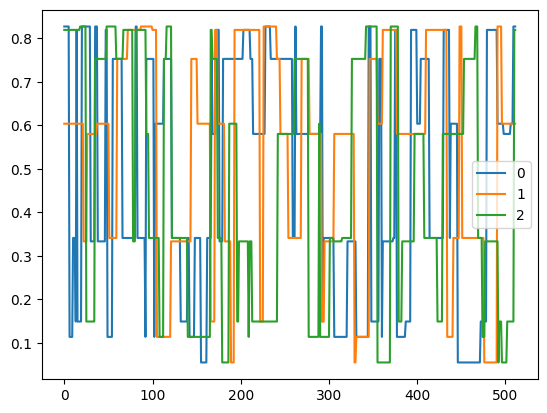

In [9]:
import matplotlib.pyplot as plt
import numpy as np
data_path = './data/samples'
dataset = MultiPhaseDataset(data_path, [512,512])

plt.figure()
plt.plot(dataset[0][0] + 0.0001 * np.random.rand(dataset[0][0].shape[0]), label=dataset[0][1])
plt.plot(dataset[20][0] + 0.0001 * np.random.rand(dataset[0][0].shape[0]), label=dataset[20][1])
plt.plot(dataset[40][0] + 0.0001 * np.random.rand(dataset[0][0].shape[0]), label=dataset[40][1])
plt.legend()
plt.show()

train, val = random_split(dataset, [800, 4000])

In [43]:
from motion_code import MotionCode
import numpy as np
from data_processing import process_data_for_motion_codes

# In this example, we use ItalyPowerDemand dataset. First we load dataset include Y-values of the series and their labels
name = 'AM_rows'
def load_data(dataset):
    Ys= []
    labels = []
    for each in dataset:
        Y, label = each
        Ys.append(Y)
        labels.append(label)
    return np.expand_dims(np.stack(Ys, axis=0), axis=1), np.stack(labels, axis=0)

# Then we process the data for motion code model and generate X-variable, which is needed for training.
Y_train, labels_train = load_data(train)
print(Y_train.shape, labels_train.shape)
X_train, Y_train, labels_train = process_data_for_motion_codes(Y_train, labels_train)

# Now we load the test set
Y_test, labels_test = load_data(val)
X_test, Y_test, labels_test = process_data_for_motion_codes(Y_test, labels_test)

print(X_train.shape, Y_train.shape, labels_train.shape)
print(X_test.shape, Y_test.shape, labels_test.shape)


(800, 1, 512) (800,)
(800, 512) (800, 512) (800,)
(4000, 512) (4000, 512) (4000,)


In [26]:
# Next we build the default motion code model for both forecasting and classification
model = MotionCode(m=10, Q=1, latent_dim=3, sigma_y=0.1)

# Then we train model on the given X_train, Y_train, label_train set and saved it to a file named test_model.
model_path = 'saved_models/' + 'test_model'
model.fit(X_train, Y_train, labels_train, model_path)

In [27]:
import numpy as np

# Next we load the model and perform classification on 10 random test time series.
model.load(model_path)
num_test = labels_test.shape[0]
random_indices = np.random.choice(np.arange(num_test), size=10, replace=False)
predicted_labels = []
for ind in random_indices:
    predicted_labels.append(model.classify_predict(X_test[ind], Y_test[ind]))
print('True label:', list(labels_test[random_indices]))
print('Predicted label:', predicted_labels)

True label: [1, 2, 2, 0, 0, 0, 2, 0, 2, 1]
Predicted label: [1, 0, 1, 0, 1, 2, 1, 0, 0, 0]


In [28]:
# Now we can go on to perform prediction on the whole test set and get accuracy
acc = model.classify_predict_on_batches(X_test_list=X_test, Y_test_list=Y_test, true_labels=labels_test)
print('Accurary:', acc)

Accurary: 0.455


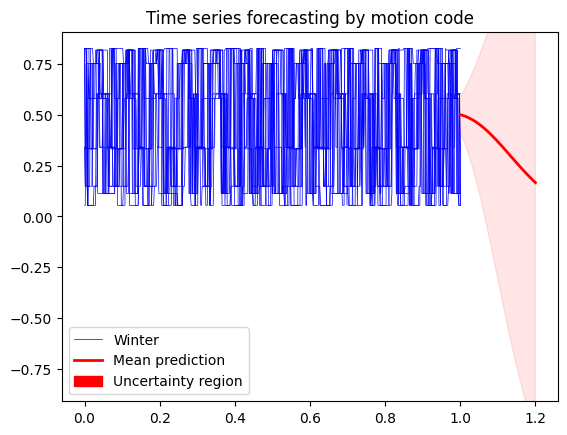

In [29]:
# Next we can use the same model to make prediction on a future interval.
# The X-variable in the previous cell is normalized to [0, 1]
# Note that the model make a average prediction over the whole collection of time series
# The prediciton is therefore made for the underlying stochastic process and not for the individual time series

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# We predict on test time horizon [1, 1.2] with 20 time steps
test_time_horizon = np.linspace(1, 1.2, 20)

# label is the label for the stochastic process we predict
mean, covar = model.forecast_predict(test_time_horizon, label=0)
std = np.sqrt(np.diag(covar)).reshape(-1)

# We plot all the time series on the horizon [0, 1]
X = X_train[labels_train==0, :]
Y = Y_train[labels_train==0, :]
plt.plot(X[0], Y[0], c='blue', lw=0.5, zorder=1, label='Winter')
for i in range(1, X.shape[0]):
    plt.plot(X[i], Y[i], c='blue', lw=0.5, zorder=1)

# Then we plot our prediction with uncertainty on test time horizon = [1, 1.2]
plt.plot(test_time_horizon, mean, c='red', lw=2, zorder=1, label='Mean prediction')
plt.fill_between(test_time_horizon, mean+2*std, mean-2*std, color='red', alpha=0.1, zorder=1)

# Plot setting and plot show
handle_list, _ = plt.gca().get_legend_handles_labels()
handle_list.append(mpatches.Patch(color='red', label='Uncertainty region'))
plt.legend(handles=handle_list, fontsize='10', loc ="lower left")
M = 1.1*max(np.max(np.abs(Y_train)), np.max(np.abs(Y_test)))
plt.ylim(-M, M)
plt.title('Time series forecasting by motion code')
plt.show()

In [16]:
import numpy as np

A = np.array([[1,0,0,0],[0.5,0.5,0,0],[0,1,0,0],[0.5,0,0.5,0],[0.25,0.25,0.25,0.25],[0,0.5,0,0.5],[0,0,1,0],[0,0,0.5,0.5],[0,0,0,1]])
B = np.linalg.inv(A.T @ A) @ A.T
print(B * 36)

[[25. 10. -5. 10.  4. -2. -5. -2.  1.]
 [-5. 10. 25. -2.  4. 10.  1. -2. -5.]
 [-5. -2.  1. 10.  4. -2. 25. 10. -5.]
 [ 1. -2. -5. -2.  4. 10. -5. 10. 25.]]


In [15]:
30./36

0.8333333333333334